# Data Cleaning and EDA


- Data : Raw_Electricity_Data.csv

Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Data

In [2]:
df = pd.read_csv("../Data/Raw_Electricity_Data.csv")
df.head()

,time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Precipitation,CloudCover,Temperature,Snowfall,Wind
0,2007-01-01 00:00:00,2.537017,0.092217,241.228917,10.486667,0.0,0.291667,0.000000,1.329846e-07,0.999695,286.43298,0.0,9.663516
1,2007-01-01 02:00:00,2.562000,0.098383,243.232917,10.470000,0.0,0.300000,0.000000,2.353721e-07,0.556274,285.98602,0.0,8.988889
2,2007-01-01 04:00:00,2.475983,0.094917,242.402417,10.130000,0.0,0.291667,0.000000,3.708734e-09,0.164459,284.50214,0.0,6.604268
3,2007-01-01 06:00:00,2.451500,0.096500,240.768000,10.111667,0.0,0.275000,0.000000,0.000000e+00,0.197144,283.30905,0.0,7.486063
4,2007-01-01 08:00:00,2.793933,0.072850,240.461000,11.550000,0.0,0.025000,6.016667,2.053049e-08,0.172791,282.31317,0.0,8.071110


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17295 entries, 0 to 17294
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   time                   17295 non-null  object 
 1   Global_active_power    16909 non-null  float64
 2   Global_reactive_power  16909 non-null  float64
 3   Voltage                16909 non-null  float64
 4   Global_intensity       16909 non-null  float64
 5   Sub_metering_1         16909 non-null  float64
 6   Sub_metering_2         16909 non-null  float64
 7   Sub_metering_3         16909 non-null  float64
 8   Precipitation          17295 non-null  float64
 9   CloudCover             17115 non-null  float64
 10  Temperature            17171 non-null  float64
 11  Snowfall               17295 non-null  float64
 12  Wind                   17295 non-null  float64
dtypes: float64(12), object(1)
memory usage: 1.7+ MB


Conversion of time from Object to DateTime.

In [4]:
df['time'] = pd.to_datetime(df['time'])

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17295 entries, 0 to 17294
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   time                   17295 non-null  datetime64[ns]
 1   Global_active_power    16909 non-null  float64       
 2   Global_reactive_power  16909 non-null  float64       
 3   Voltage                16909 non-null  float64       
 4   Global_intensity       16909 non-null  float64       
 5   Sub_metering_1         16909 non-null  float64       
 6   Sub_metering_2         16909 non-null  float64       
 7   Sub_metering_3         16909 non-null  float64       
 8   Precipitation          17295 non-null  float64       
 9   CloudCover             17115 non-null  float64       
 10  Temperature            17171 non-null  float64       
 11  Snowfall               17295 non-null  float64       
 12  Wind                   17295 non-null  float64       
dtypes

Null value Identification

In [6]:
df.isna().sum()

time                       0
Global_active_power      386
Global_reactive_power    386
Voltage                  386
Global_intensity         386
Sub_metering_1           386
Sub_metering_2           386
Sub_metering_3           386
Precipitation              0
CloudCover               180
Temperature              124
Snowfall                   0
Wind                       0
dtype: int64

In [7]:
df[df['Global_active_power'].isna()]


,time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Precipitation,CloudCover,Temperature,Snowfall,Wind
1405,2007-04-28 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.006256,286.32025,0.000000e+00,1.878398
1406,2007-04-28 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.026245,285.62940,0.000000e+00,1.441969
1407,2007-04-28 06:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.000000,286.65405,0.000000e+00,2.334615
1408,2007-04-28 08:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.000000,291.37030,0.000000e+00,2.353884
1409,2007-04-28 10:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.649095e-10,0.000000,295.79346,0.000000e+00,1.818835
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17162,2010-11-30 22:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.353424,271.24725,3.311369e-11,4.663798
17171,2010-12-01 16:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.649095e-09,1.000000,270.71980,2.649095e-09,2.783768
17172,2010-12-01 18:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.934108e-09,1.000000,270.46063,9.900994e-09,1.467966
17173,2010-12-01 20:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.470248e-08,0.988739,270.29550,1.463625e-08,0.495738


In [8]:
# Need to look into this code: 

s = df['Global_active_power'].isnull()

groups = (s != s.shift()).cumsum()

null_ranges = (
    df[s]
    .groupby(groups[s])
    .apply(lambda x: (x.index[0], x.index[-1], len(x)))
)

print(null_ranges)

Global_active_power
2       (1405, 1434, 30)
4     (10731, 10756, 26)
6      (11465, 11470, 6)
8     (13287, 13319, 33)
10    (13659, 13670, 12)
12    (13995, 14006, 12)
14    (14093, 14108, 16)
16    (14367, 14378, 12)
18    (14727, 14738, 12)
20    (15099, 15110, 12)
22    (15459, 15470, 12)
24    (15831, 15842, 12)
26    (15902, 15960, 59)
28    (16203, 16214, 12)
30    (16361, 16403, 43)
32    (16563, 16574, 12)
34    (16935, 16946, 12)
36    (17114, 17162, 49)
38     (17171, 17174, 4)
dtype: object


In [9]:
df.iloc[1400:1445] 
# to check the null value series range: - 30  

,time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Precipitation,CloudCover,Temperature,Snowfall,Wind
1400,2007-04-27 16:00:00,0.415533,0.122183,235.272417,1.808333,0.000000,0.491667,0.000000,0.000000e+00,0.000000,298.30896,0.0,2.032198
1401,2007-04-27 18:00:00,1.174017,0.202883,235.336917,5.190000,6.966667,0.483333,0.000000,0.000000e+00,0.000000,295.78400,0.0,0.497330
1402,2007-04-27 20:00:00,2.192933,0.125617,233.791333,9.420000,7.800000,0.441667,13.366667,0.000000e+00,0.007507,291.35950,0.0,0.395548
1403,2007-04-27 22:00:00,1.902583,0.101167,235.567500,8.096667,0.000000,0.325000,8.200000,0.000000e+00,0.003754,290.48737,0.0,0.179785
1404,2007-04-28 00:00:00,1.082762,0.136190,233.986190,4.638095,0.000000,0.857143,0.000000,0.000000e+00,0.000000,286.61023,0.0,0.871761
1405,2007-04-28 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.006256,286.32025,0.0,1.878398
1406,2007-04-28 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.026245,285.62940,0.0,1.441969
1407,2007-04-28 06:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.000000,286.65405,0.0,2.334615
1408,2007-04-28 08:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.000000,291.37030,0.0,2.353884
1409,2007-04-28 10:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.649095e-10,0.000000,295.79346,0.0,1.818835


Feature Extracting 
- Extracting each Day,Hour,Minutes,Month,Year from time

In [10]:
df['Year'] = df['time'].dt.year

In [11]:
df['hour'] = df['time'].dt.hour
df['minutes'] = df['time'].dt.minute

In [12]:
df['month'] = df["time"].dt.month

In [13]:
df['Day'] = df['time'].dt.day

In [14]:
df["Date"] = df['time'].dt.date

In [15]:
df['Time'] = df['time'].dt.time

Setting time as index

In [16]:
df = df.set_index('time')

Filling the null values

In [17]:
df.interpolate(method='time', inplace=True)

C:\Users\vssuj\AppData\Local\Temp\ipykernel_24904\997848166.py:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df.interpolate(method='time', inplace=True)


checking the data after the fill.

In [18]:
df.isna().sum()

Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
Precipitation            0
CloudCover               0
Temperature              0
Snowfall                 0
Wind                     0
Year                     0
hour                     0
minutes                  0
month                    0
Day                      0
Date                     0
Time                     0
dtype: int64

In [19]:
df.iloc[1405:1425]

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Precipitation,CloudCover,Temperature,Snowfall,Wind,Year,hour,minutes,month,Day,Date,Time
time,,,,,,,,,,,,,,,,,,,
2007-04-28 02:00:00,1.065856,0.135032,234.007634,4.567041,0.0,0.849318,0.169019,0.000000e+00,0.006256,286.32025,0.0,1.878398,2007,2,0,4,28,2007-04-28,02:00:00
2007-04-28 04:00:00,1.048951,0.133873,234.029077,4.495987,0.0,0.841494,0.338038,0.000000e+00,0.026245,285.62940,0.0,1.441969,2007,4,0,4,28,2007-04-28,04:00:00
2007-04-28 06:00:00,1.032045,0.132714,234.050521,4.424933,0.0,0.833669,0.507056,0.000000e+00,0.000000,286.65405,0.0,2.334615,2007,6,0,4,28,2007-04-28,06:00:00
2007-04-28 08:00:00,1.015139,0.131556,234.071964,4.353879,0.0,0.825845,0.676075,0.000000e+00,0.000000,291.37030,0.0,2.353884,2007,8,0,4,28,2007-04-28,08:00:00
2007-04-28 10:00:00,0.998234,0.130397,234.093408,4.282825,0.0,0.818020,0.845094,2.649095e-10,0.000000,295.79346,0.0,1.818835,2007,10,0,4,28,2007-04-28,10:00:00
2007-04-28 12:00:00,0.981328,0.129238,234.114851,4.211770,0.0,0.810196,1.014113,1.589457e-09,0.000000,297.95392,0.0,1.610154,2007,12,0,4,28,2007-04-28,12:00:00
2007-04-28 14:00:00,0.964423,0.128080,234.136295,4.140716,0.0,0.802371,1.183132,3.708734e-09,0.145874,298.90510,0.0,0.757414,2007,14,0,4,28,2007-04-28,14:00:00
2007-04-28 16:00:00,0.947517,0.126921,234.157738,4.069662,0.0,0.794547,1.352151,4.900826e-09,0.000000,298.63095,0.0,0.893967,2007,16,0,4,28,2007-04-28,16:00:00
2007-04-28 18:00:00,0.930611,0.125762,234.179182,3.998608,0.0,0.786722,1.521169,1.153681e-07,0.023743,296.39350,0.0,0.763186,2007,18,0,4,28,2007-04-28,18:00:00


In [20]:
df.nunique()

Global_active_power      16972
Global_reactive_power    11081
Voltage                  16966
Global_intensity         14720
Sub_metering_1            1395
Sub_metering_2            1751
Sub_metering_3            2688
Precipitation             1521
CloudCover                7760
Temperature              17085
Snowfall                   336
Wind                     17282
Year                         4
hour                        12
minutes                      1
month                       12
Day                         31
Date                      1441
Time                        12
dtype: int64

EDA - Boxplot

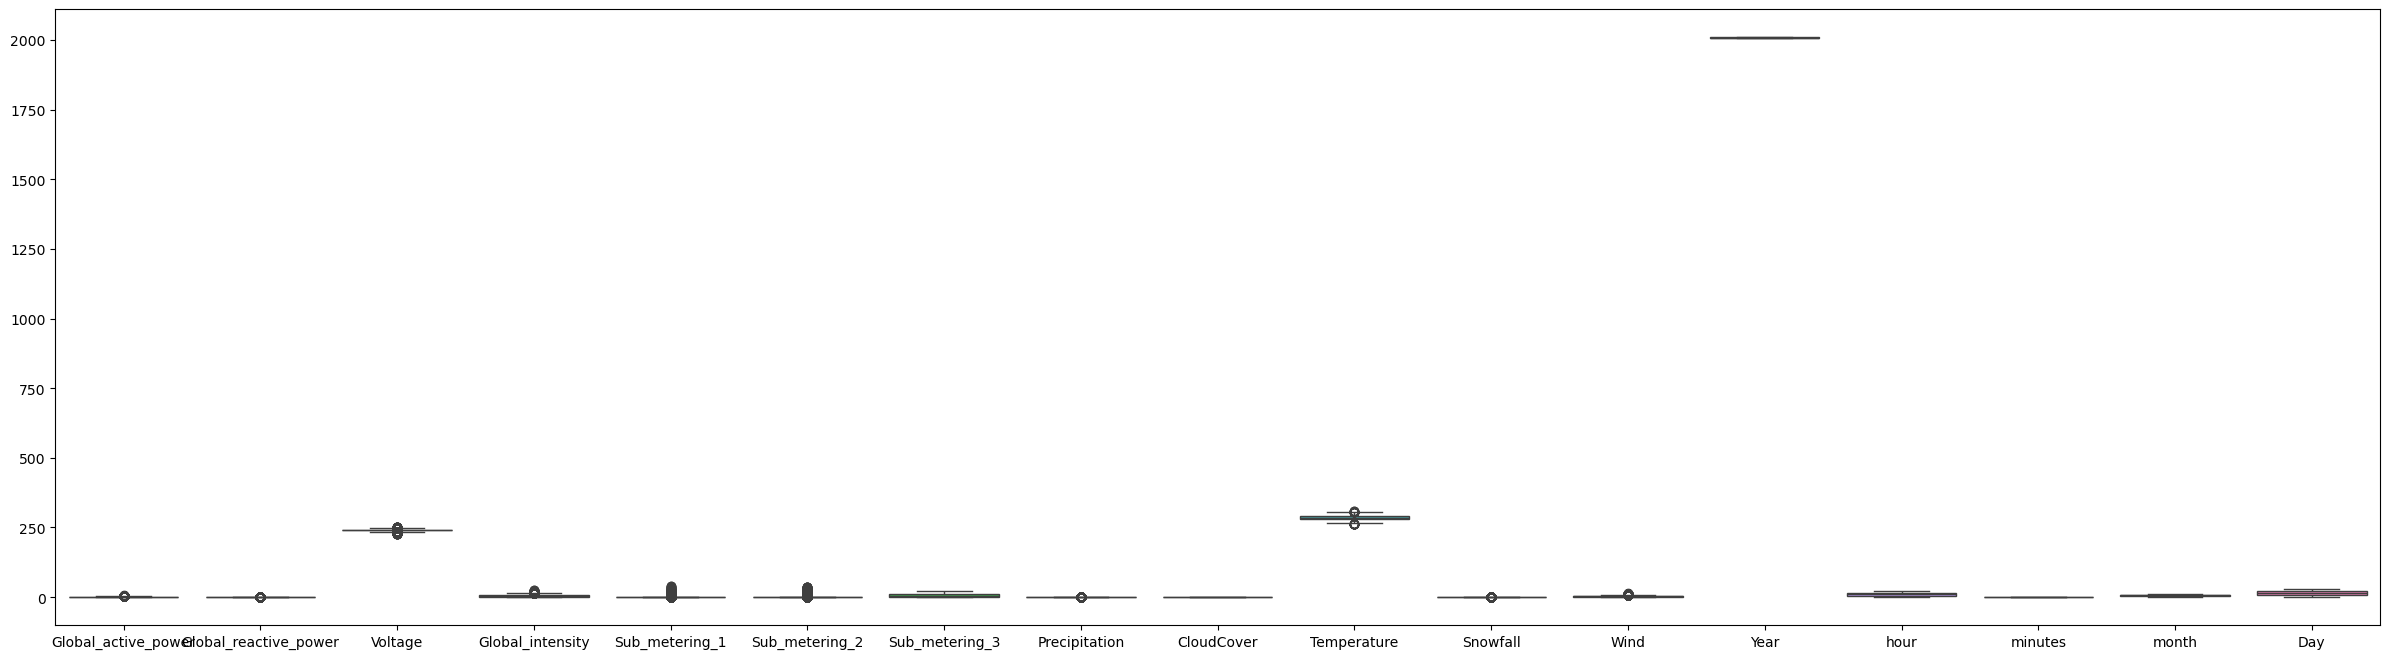

In [21]:
plt.figure(figsize=(30,8))
sns.boxplot(df)
plt.show()

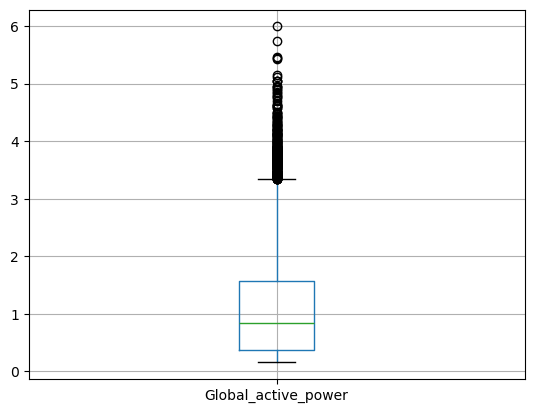

In [22]:
df[['Global_active_power']].boxplot()

plt.show()

- Graph Shows outliers but we are not removing it as outliers or sudden fluctuations in power can be happened in real life so it better to not remove it, if we remove it model will not be trained on that kind of data which will effect the performance of model.

In [23]:
df.groupby('Year')['Global_active_power'].describe()

,count,mean,std,min,25%,50%,75%,max
Year,,,,,,,,
2007,4380.0,1.114878,0.921983,0.154750,0.313650,0.812353,1.641592,5.993667
2008,4393.0,1.072424,0.838816,0.154117,0.351333,0.797950,1.568200,5.457283
2009,4381.0,1.079015,0.771538,0.229917,0.387417,0.874700,1.539600,5.116133
2010,4141.0,1.056089,0.705048,0.230933,0.431950,0.843933,1.515750,4.932783


In [24]:
q1 = df.Global_active_power.quantile(.25)
q3 = df.Global_active_power.quantile(.75)

iqr = q3-q1

ub = q3+ 1.5*iqr
lb = q1- 1.5*iqr

(df.Global_active_power >=(ub)).sum()

np.int64(268)

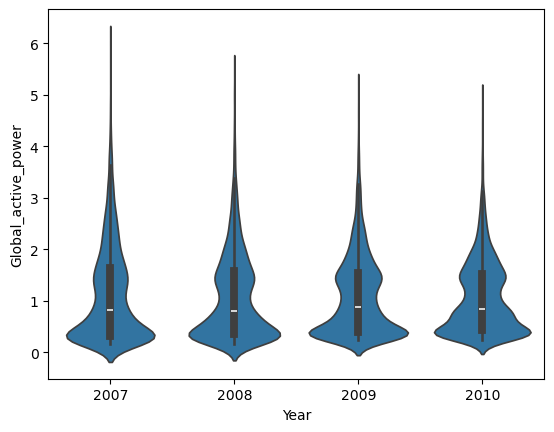

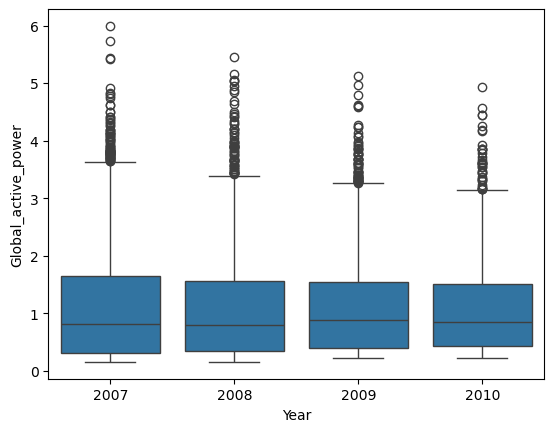

In [25]:
sns.violinplot(x='Year', y='Global_active_power', data=df)
plt.show()
sns.boxplot(x='Year', y='Global_active_power', data=df)
plt.show()

- Volin plot shows the distribution of the data in different years. 
- box plot shows outliers in different years

In [26]:
yearly = df.groupby('Year')['Global_active_power'].median().reset_index()
yearly

,Year,Global_active_power
0,2007,0.812353
1,2008,0.797950
2,2009,0.874700
3,2010,0.843933


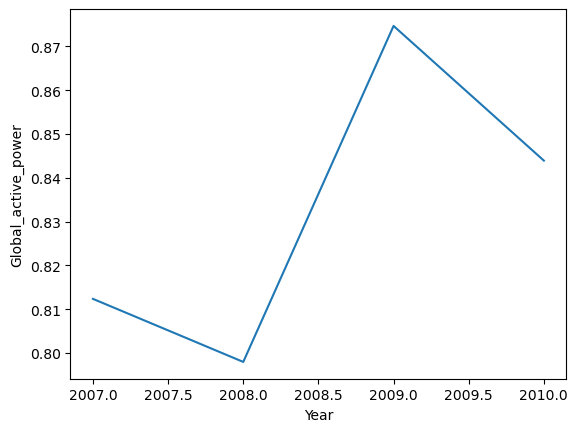

In [27]:
sns.lineplot(x = yearly['Year'], y = yearly['Global_active_power'])
plt.show()

- > Graph Analysis:
- This graph illustrates the yearly trend of Global Active Power from 2007 to 2010 using the median values. The median was preferred over the mean because the dataset contains skewness and several extreme high-consumption observations that could disproportionately influence the average. The trend indicates a gradual increase in typical power consumption until 2009, followed by a slight decline in 2010. Overall, the yearly consumption pattern appears relatively stable with minor fluctuations over time.

In [28]:
monthly = df.groupby('month')["Global_active_power"].median().reset_index()
monthly["Avg_Temp"]= df.groupby('month')['Temperature'].median()
monthly

,month,Global_active_power,Avg_Temp
0,1,1.299067,NaN
1,2,0.810525,276.922240
2,3,0.957233,278.867795
3,4,0.817417,280.255860
4,5,0.850117,284.365715
5,6,0.777808,287.514725
6,7,0.595217,290.100290
7,8,0.569617,292.122350
8,9,0.866575,291.302080
9,10,0.841242,288.093080


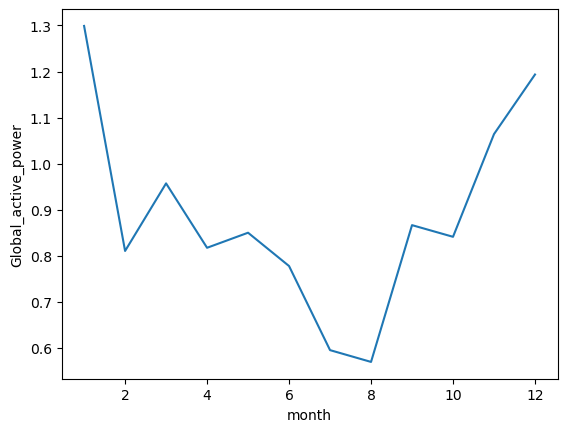

In [29]:
sns.lineplot(x = monthly["month"], y = monthly['Global_active_power'])
plt.show()

- In Monthly Analysis it can be clearly visible that inn moths 5 - 9 there is decrease in usage of power it is the trend we can see from this graph. for more detailed we are using year wise trend analysis in next graph.

In [30]:
yearly_months = df.groupby(['Year','month'])["Global_active_power"].mean().reset_index()
yearly_months

,Year,month,Global_active_power
0,2007,1,1.430063
1,2007,2,1.154997
2,2007,3,1.238326
3,2007,4,0.965662
4,2007,5,1.061256
5,2007,6,0.892380
6,2007,7,0.862432
7,2007,8,0.908295
8,2007,9,1.029676
9,2007,10,1.088599


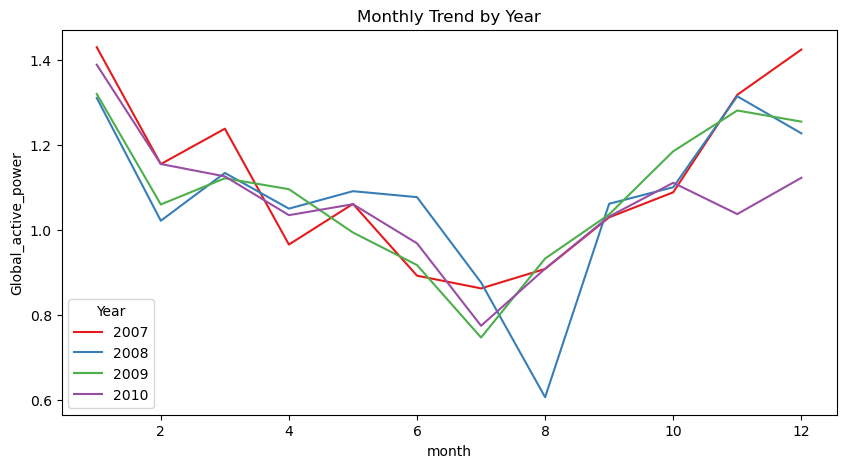

In [31]:
plt.figure(figsize=(10,5))



sns.lineplot(
    x=yearly_months['month'],
    y=yearly_months['Global_active_power'],
    hue=yearly_months['Year'],
    palette='Set1'
)

plt.title("Monthly Trend by Year")
plt.show()

- Its also showing similar patterns as the whole month data is showing so in each year there is an decrease in power usage at 5 - 9 and then get back to high usage.

In [32]:
daily_trend = df.groupby(df['Day'])['Global_active_power'].median().reset_index()

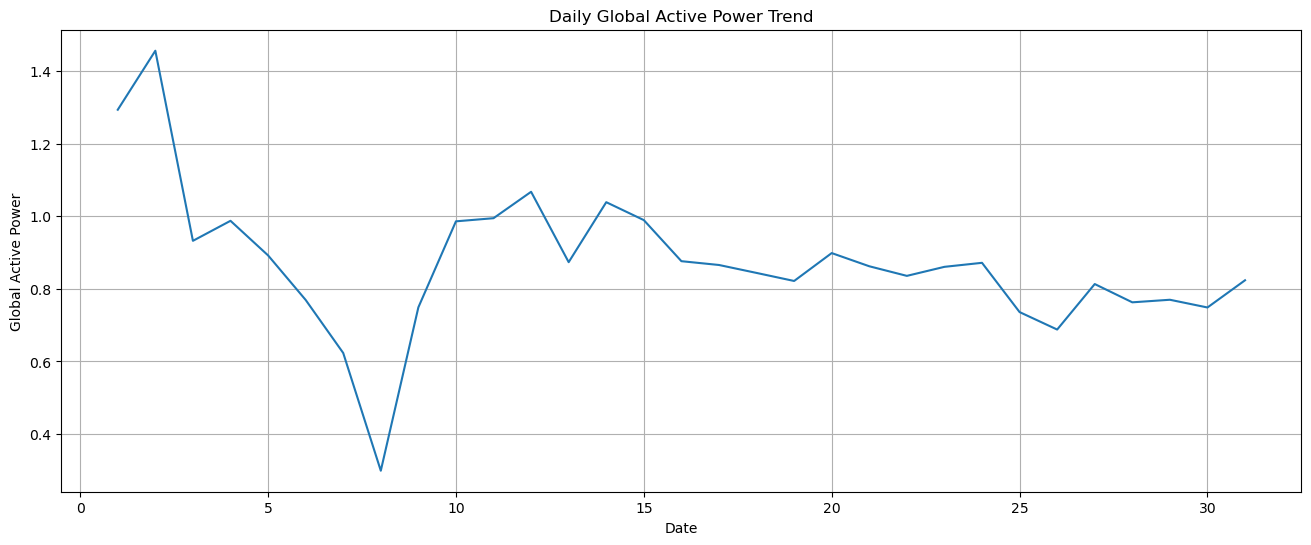

In [33]:
plt.figure(figsize=(16,6))

plt.plot(
    daily_trend['Day'],
    daily_trend['Global_active_power']
)

plt.title('Daily Global Active Power Trend')
plt.xlabel('Date')
plt.ylabel('Global Active Power')

plt.grid(True)
plt.show()

In [34]:
daily_data = df.groupby(['month','Date'])['Global_active_power'].mean().reset_index()
daily_data

,month,Date,Global_active_power
0,1,2007-01-01,1.909031
1,1,2007-01-02,1.267194
2,1,2007-01-03,0.359419
3,1,2007-01-04,1.934689
4,1,2007-01-05,1.155457
...,...,...,...
1436,12,2010-12-07,0.770537
1437,12,2010-12-08,0.367846
1438,12,2010-12-09,1.119508
1439,12,2010-12-10,1.097008


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17295 entries, 2007-01-01 00:00:00 to 2010-12-11 22:00:00
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Global_active_power    17295 non-null  float64
 1   Global_reactive_power  17295 non-null  float64
 2   Voltage                17295 non-null  float64
 3   Global_intensity       17295 non-null  float64
 4   Sub_metering_1         17295 non-null  float64
 5   Sub_metering_2         17295 non-null  float64
 6   Sub_metering_3         17295 non-null  float64
 7   Precipitation          17295 non-null  float64
 8   CloudCover             17295 non-null  float64
 9   Temperature            17295 non-null  float64
 10  Snowfall               17295 non-null  float64
 11  Wind                   17295 non-null  float64
 12  Year                   17295 non-null  int32  
 13  hour                   17295 non-null  int32  
 14  minutes            

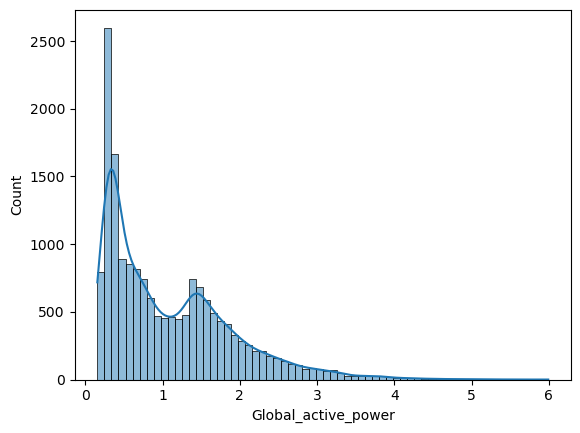

In [36]:
sns.histplot(df['Global_active_power'],kde=True)
plt.show()

In [37]:
heatmap_data = df.drop('minutes',axis=1)

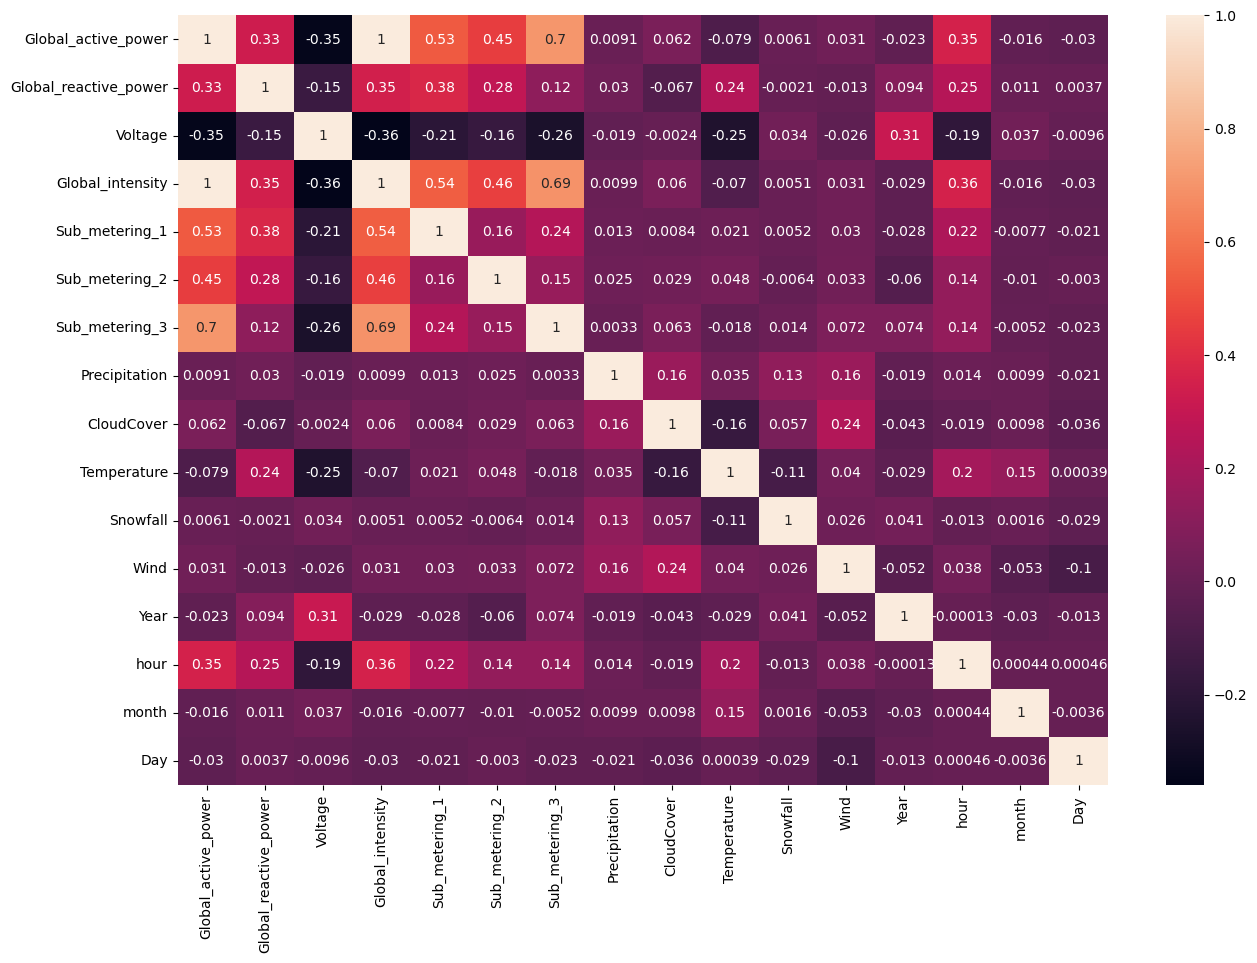

In [38]:
plt.figure(figsize=(15,10))
sns.heatmap(heatmap_data.corr(numeric_only=True),annot=True)
plt.show()

- Found out global intensity showing proper correlation with global_active power.

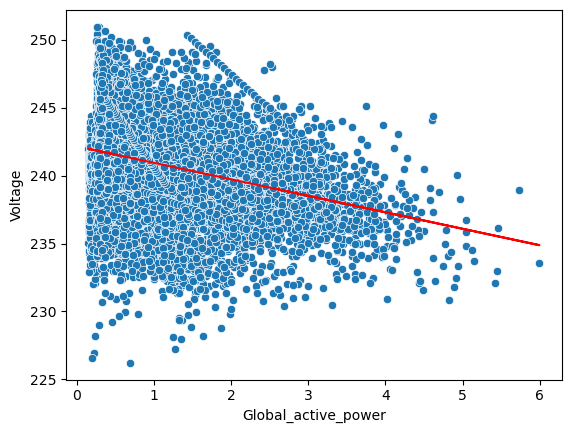

In [39]:
x = df['Global_active_power']
y = df['Voltage']
m, b = np.polyfit(x, y, 1)
sns.scatterplot(x=df["Global_active_power"], y=df["Voltage"])
plt.plot(x, m*x + b, color="red")
plt.show()

- Global_active_power and Voltage show a negative correlation
- which is expected behavior in electrical systems. Since the correlation is not excessively high in magnitude and does not indicate redundancy, there is no need to remove the feature.

In [40]:
# Needed to look into this code.


from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df.select_dtypes(include=['float64', 'int64'])

vif_data = pd.DataFrame()

vif_data["Feature"] = X.columns

vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(len(X.columns))
]

print(vif_data)

                  Feature          VIF
0     Global_active_power  4772.069117
1   Global_reactive_power     8.977856
2                 Voltage  1419.520380
3        Global_intensity  4866.232401
4          Sub_metering_1     1.915686
5          Sub_metering_2     1.665445
6          Sub_metering_3     4.973632
7           Precipitation     1.150518
8              CloudCover     2.306604
9             Temperature  1451.423211
10               Snowfall     1.035285
11                   Wind     4.636689


- Global_active_power and Global_intensity exhibited near-perfect correlation. This relationship is expected from electrical system principles, where active power is proportional to voltage and current intensity. Since household voltage remains relatively stable, both variables carry highly redundant information. To reduce multicollinearity and avoid redundant feature representation, Global_intensity was removed from the final feature set.

In [41]:
new_df = df.drop('Global_intensity',axis=1)
new_df

,Global_active_power,Global_reactive_power,Voltage,Sub_metering_1,Sub_metering_2,Sub_metering_3,Precipitation,CloudCover,Temperature,Snowfall,Wind,Year,hour,minutes,month,Day,Date,Time
time,,,,,,,,,,,,,,,,,,
2007-01-01 00:00:00,2.537017,0.092217,241.228917,0.000,0.291667,0.000000,1.329846e-07,0.999695,286.43298,0.0,9.663516,2007,0,0,1,1,2007-01-01,00:00:00
2007-01-01 02:00:00,2.562000,0.098383,243.232917,0.000,0.300000,0.000000,2.353721e-07,0.556274,285.98602,0.0,8.988889,2007,2,0,1,1,2007-01-01,02:00:00
2007-01-01 04:00:00,2.475983,0.094917,242.402417,0.000,0.291667,0.000000,3.708734e-09,0.164459,284.50214,0.0,6.604268,2007,4,0,1,1,2007-01-01,04:00:00
2007-01-01 06:00:00,2.451500,0.096500,240.768000,0.000,0.275000,0.000000,0.000000e+00,0.197144,283.30905,0.0,7.486063,2007,6,0,1,1,2007-01-01,06:00:00
2007-01-01 08:00:00,2.793933,0.072850,240.461000,0.000,0.025000,6.016667,2.053049e-08,0.172791,282.31317,0.0,8.071110,2007,8,0,1,1,2007-01-01,08:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2010-12-11 14:00:00,1.555850,0.168850,236.979333,0.000,0.258333,10.625000,0.000000e+00,1.000000,278.62927,0.0,1.694674,2010,14,0,12,11,2010-12-11,14:00:00
2010-12-11 16:00:00,1.908883,0.191567,233.290500,0.000,0.608333,5.958333,1.589457e-09,1.000000,278.68933,0.0,0.930473,2010,16,0,12,11,2010-12-11,16:00:00
2010-12-11 18:00:00,2.336417,0.105783,231.377417,0.175,0.000000,6.566667,1.298057e-08,1.000000,278.19742,0.0,0.700579,2010,18,0,12,11,2010-12-11,18:00:00


In [45]:
heatmap_data2 = new_df.drop('minutes',axis=1)

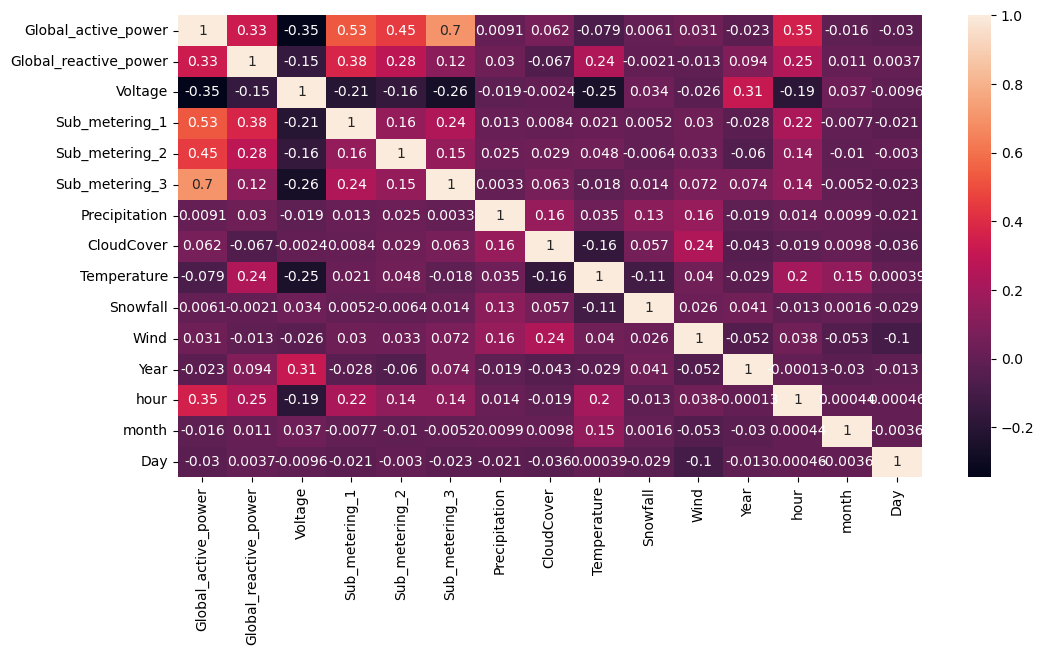

In [46]:
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data2.corr(numeric_only=True),annot=True)
plt.show()

- Cleaning of data  removing object columns with date and time, Already features like hours, minutes are extracted from time and features like day, month, year are extracted from date 

In [43]:
new_df = new_df.drop(['Date','Time'],axis=1)

- Saving of the cleaned dataset.
- as cleaned_data.csv

In [44]:
new_df.to_csv('../Data/cleaned_data.csv', index=False)

# Summary

- Missing values handled using time interpolation
- Temporal features extracted
- Correlation and multicollinearity analyzed
- Redundant features removed
- Cleaned dataset prepared for model training


- > Data saved as cleaned_data.csv